# Eksperimen Sentiment Analysis - Olist Customer Reviews
**Nama:** Ratih Ayudia Nurmala  
**Dataset:** Brazilian E-Commerce (Olist)  
**Tujuan:** Klasifikasi sentimen review customer (positif/negatif)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
reviews = pd.read_csv('../data_raw/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data_raw/olist_orders_dataset.csv')


print("Reviews Shape", reviews.shape)
print("Orders Shape", orders.shape)
reviews.head()

Reviews Shape (99224, 7)
Orders Shape (99441, 8)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## Exploratory Data Analysis (EDA)

In [5]:
print("=== REVIEWS INFO ===")
print(reviews.info())
print("\n=== MISSING VALUES ===")
print(reviews.isnull().sum())

=== REVIEWS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None

=== MISSING VALUES ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


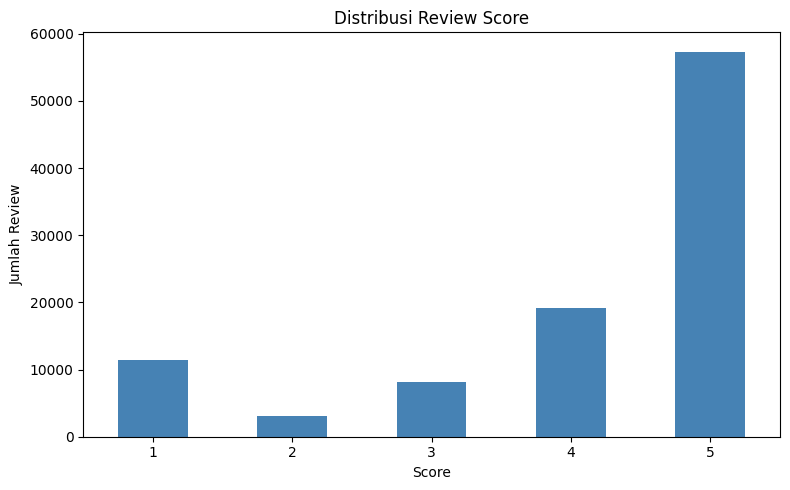

In [6]:
plt.figure(figsize=(8, 5))
reviews['review_score'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribusi Review Score')
plt.xlabel('Score')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
total = len(reviews)
punya_komentar = reviews['review_comment_message'].notna().sum()
print(f"Total reviews: {total}")
print(f"Reviews dengan komentar: {punya_komentar} ({punya_komentar/total*100:.1f}%)")
print(f"Reviews tanpa komentar: {total - punya_komentar} ({(total-punya_komentar)/total*100:.1f}%)")

Total reviews: 99224
Reviews dengan komentar: 40977 (41.3%)
Reviews tanpa komentar: 58247 (58.7%)


In [8]:
# Drop score 3 (netral), buat label biner
df = reviews[reviews['review_score'] != 3].copy()
df['sentiment'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0)

print("Distribusi Sentimen:")
print(df['sentiment'].value_counts())
print(f"\nPositif (1): {df['sentiment'].sum()}")
print(f"Negatif (0): {(df['sentiment'] == 0).sum()}")

Distribusi Sentimen:
sentiment
1    76470
0    14575
Name: count, dtype: int64

Positif (1): 76470
Negatif (0): 14575


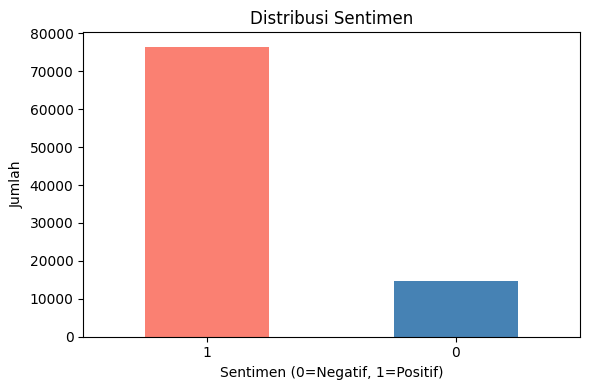

In [9]:
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen (0=Negatif, 1=Positif)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

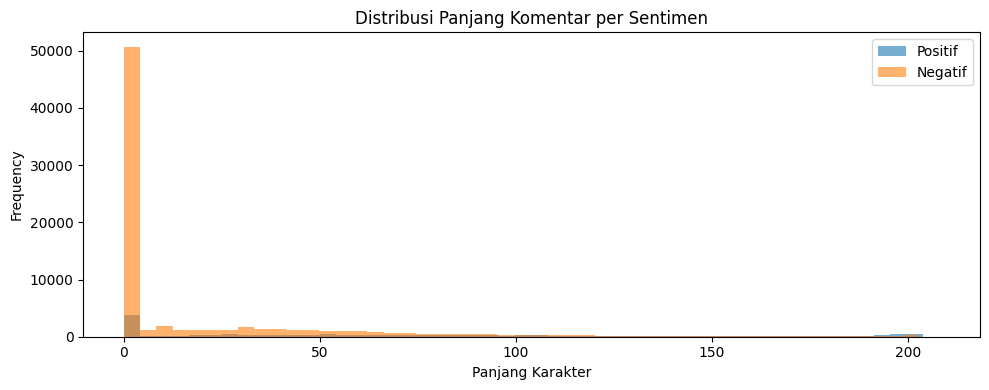

             count       mean        std  min  25%   50%    75%    max
sentiment                                                             
0          14575.0  74.217907  67.289119  0.0  0.0  59.0  124.0  208.0
1          76470.0  18.758062  36.496689  0.0  0.0   0.0   25.0  207.0


In [10]:
df['comment_length'] = df['review_comment_message'].fillna('').apply(len)

plt.figure(figsize=(10, 4))
df.groupby('sentiment')['comment_length'].plot(kind='hist', bins=50, alpha=0.6, legend=True)
plt.title('Distribusi Panjang Komentar per Sentimen')
plt.xlabel('Panjang Karakter')
plt.legend(['Positif', 'Negatif'])
plt.tight_layout()
plt.show()

print(df.groupby('sentiment')['comment_length'].describe())

In [11]:
kolom_penting = ['review_score', 'review_comment_message', 'sentiment']
print(df[kolom_penting].isnull().sum())

review_score                  0
review_comment_message    53625
sentiment                     0
dtype: int64


## Preprocessing

In [12]:
import re

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-záéíóúàãõâêôç\s]', '', text)  # keep portugis chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_comment'] = df['review_comment_message'].apply(clean_text)

print("Contoh hasil cleaning:")
print(df[['review_comment_message', 'clean_comment']].head(5))

Contoh hasil cleaning:
                              review_comment_message  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3              Recebi bem antes do prazo estipulado.   
4  Parabéns lojas lannister adorei comprar pela I...   

                                       clean_comment  
0                                                     
1                                                     
2                                                     
3               recebi bem antes do prazo estipulado  
4  parabéns lojas lannister adorei comprar pela i...  


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
X = tfidf.fit_transform(df['clean_comment'])
y = df['sentiment']

print("Shape X (TF-IDF matrix):", X.shape)
print("Shape y (label):", y.shape)

Shape X (TF-IDF matrix): (91045, 5000)
Shape y (label): (91045,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribusi:\n", y_train.value_counts())
print("y_test distribusi:\n", y_test.value_counts())

X_train: (72836, 5000)
X_test: (18209, 5000)
y_train distribusi:
 sentiment
1    61176
0    11660
Name: count, dtype: int64
y_test distribusi:
 sentiment
1    15294
0     2915
Name: count, dtype: int64


In [15]:
import scipy.sparse as sp
import os

os.makedirs('../preprocessing/olist_preprocessing', exist_ok=True)

# Simpan sparse matrix
sp.save_npz('../preprocessing/olist_preprocessing/X_train.npz', X_train)
sp.save_npz('../preprocessing/olist_preprocessing/X_test.npz', X_test)

# Simpan label
y_train.to_csv('../preprocessing/olist_preprocessing/y_train.csv', index=False)
y_test.to_csv('../preprocessing/olist_preprocessing/y_test.csv', index=False)

print("Dataset preprocessed berhasil disimpan!")

Dataset preprocessed berhasil disimpan!
